# 🐶 End-to-end Multi-class Dog Breed Classification

This notebook builds an End-to-end Multi-class image Classifier using TensorFlow 2.o and TensorFlow Hub.

### 1. Problem 
#### Identifying the breed of dog from given an imageof a dog.

### 2. Data
#### Dataset from Kaggle - [https://www.kaggle.com/competitions/dog-breed-identification/data](https://www.kaggle.com/competitions/dog-breed-identification/data)

### 3. Evalution
#### The Evaluation is a file with prediction probabilities for each dog breed of each test image.

### 4. Features
#### Some information about data:
* We're dealing with images so it's best we use deep learning/transfer learning.
* There are 120 breeds of dogs (means there are 120 different classes).
* There are aroung 10,000+ images in training set (This images have labels)
* There are aroung 10,000+ images in test set (These images have no labels, because we'll have to predict them).

In [2]:
import tensorflow as tf
# import tensorflow_hub as hub # type: ignore
print("TF Version:", tf.__version__)
# print("TF Version:", hub.__version__)i


TF Version: 2.15.1


In [3]:
import tensorflow_hub as hub
print("hub version:", hub.__version__)

hub version: 0.16.1


In [4]:
# Check for GPU availability

print("GPU", "available (Yess!!)" if tf.config.list_physical_devices("GPU") else "not available")

GPU not available


In [5]:
import tensorflow as tf
print(tf.test.is_built_with_cuda())

False


In [6]:
import pandas as pd

label_csv = pd.read_csv("dog-breed-identification/labels.csv")
print(label_csv.describe())
print(label_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     000bec180eb18c7604dcecc8fe0dba07  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [7]:
label_csv["breed"].value_counts()

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
                       ... 
golden_retriever         67
brabancon_griffon        67
komondor                 67
eskimo_dog               66
briard                   66
Name: count, Length: 120, dtype: int64

<Axes: xlabel='breed'>

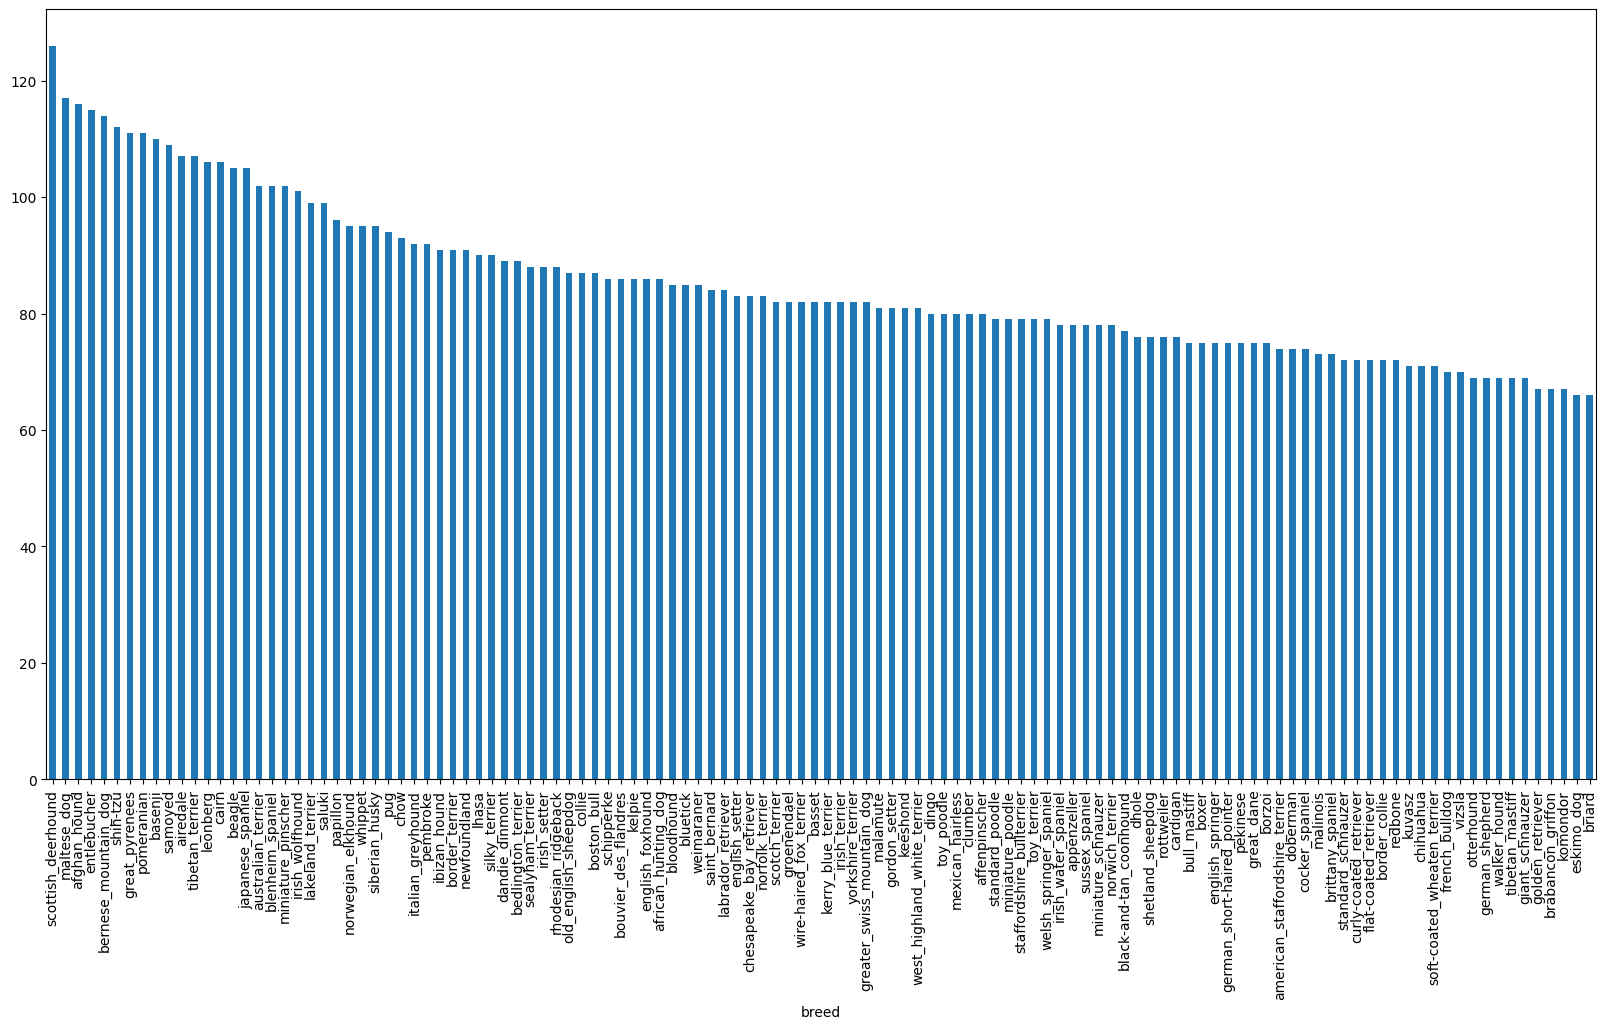

In [8]:
import matplotlib as plt
label_csv["breed"].value_counts().plot.bar(figsize=(20, 10))

In [9]:
label_csv["breed"].value_counts().median()

82.0

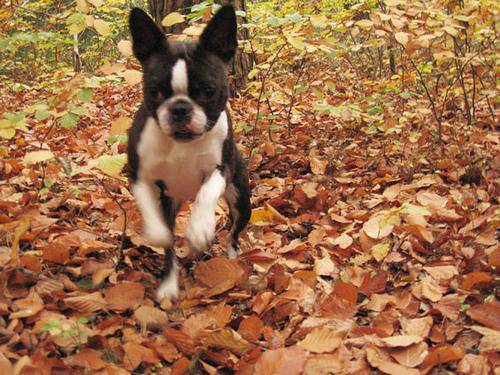

In [10]:
# View an image
from IPython.display import Image
Image("dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

In [11]:
label_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [12]:
# Creating pathnames from image ID'set
filename = ["dog-breed-identification/train/" + fname + ".jpg" for fname in label_csv["id"]]

# Check the first 10 
filename[:10]

['dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'dog-breed-identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'dog-breed-identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'dog-breed-identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'dog-breed-identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'dog-breed-identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'dog-breed-identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'dog-breed-identification/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'dog-breed-identification/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [13]:
# Check whether number of filename matches number of actual image files

import os 
if len(os.listdir("dog-breed-identification/train/")) == len(filename):
 print("filename matches the actual amount of image files")
else:
 print("filename doesn't match the actual amount of image files")

filename matches the actual amount of image files


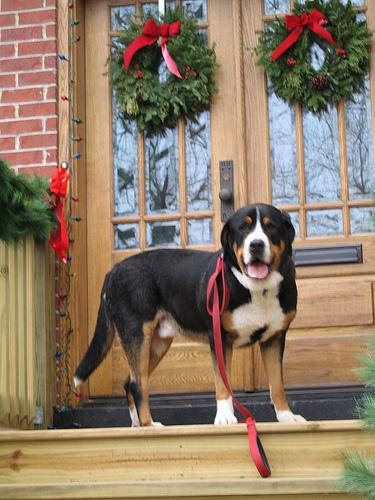

In [14]:
Image(filename[1122])

In [15]:
label_csv["breed"][1122]

'greater_swiss_mountain_dog'

In [16]:
import numpy as np
labels = label_csv["breed"].to_numpy()
# labels = np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [17]:
len(labels)

10222

In [18]:
# see if number of labels mathces the number of filename
if len(labels) == len(filename):
    print("Number of label matches the number of filename")
else:
    print("Number of label doesn't match the number of filename")

Number of label matches the number of filename


In [19]:
# Find the unique label value
unique_breeds = np.unique(labels)
len(unique_breeds)

120

In [20]:
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [21]:
# Trun a single array into an array of boolean
print(labels[1])
labels[1] == unique_breeds

dingo


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [22]:
# Turn every label into a array of boolean
boolean_labels = [label == unique_breeds for label in labels]
print(boolean_labels[:2])

print("\n length of boolean labels:", len(boolean_labels))

[array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False]), array([False, False, False, False, False, False, False, Fal

In [23]:
# Turning boolean aaray into integers
print(labels[1]) # original label
print(np.where(unique_breeds == labels[1])) # index where labels accours
print(boolean_labels[1].argmax()) # index where label accours in boolean array
print(boolean_labels[1].astype(int)) # there will be a 1 where the sample label occurs


dingo
(array([37], dtype=int64),)
37
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [24]:
print(labels[2])
print(boolean_labels[2].astype(int))

pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


## Creating own validation set

In [25]:
filename[:2]

['dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg']

In [26]:
# Setup X and y variables
X = filename
y = boolean_labels

In [27]:
# Set number of images to use for experimenting 
NUM_IMAGES = 8000 

In [28]:
import sys
print(sys.executable)


c:\Users\kisha\AppData\Local\Programs\Python\Python311\python.exe


In [29]:
import sklearn
print(sklearn.__version__)

1.8.0


In [30]:
# Let's split our data into train and validation set   
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES], y[:NUM_IMAGES], test_size=0.2, random_state=42)

len(X_train), len(y_train), len(X_val), len(y_val)

(6400, 6400, 1600, 1600)

In [31]:
X_train[:5], y_train[:5]

(['dog-breed-identification/train/2483ddc95004ffd44b14a486d94ac91b.jpg',
  'dog-breed-identification/train/91a41fe9c86b0fc3cd70a72fb29018a2.jpg',
  'dog-breed-identification/train/9000dac1467ed4a3fff4d7658bbbf3e4.jpg',
  'dog-breed-identification/train/271dfc72a582a0a9b54e833788cafad3.jpg',
  'dog-breed-identification/train/ae8693b4868b1744be1fefb328a8a486.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, 

## Preprocessing images (Turning images into Tensors)

1. Take an image filepath as input
2. Use TensorFlow to read the file and save it to a variable, `image`
3. Turn `image` (a jpg) into Tensors
4. Resize the `image` to be shape of (244, 244)
5. Return the modified `image`

In [32]:
# Convert images into NumPy array
from matplotlib.pyplot import imread
image = imread(filename[42])
image.shape

(257, 350, 3)

In [33]:
image.max(), image.min()

(255, 0)

In [34]:
# Normal array
print(image[:2])
print(image.shape)

[[[ 89 137  89]
  [ 76 124  76]
  [ 63 111  61]
  ...
  [ 77 133  86]
  [ 76 134  86]
  [ 76 134  86]]

 [[ 72 119  75]
  [ 67 114  68]
  [ 63 110  64]
  ...
  [ 75 131  84]
  [ 74 132  84]
  [ 74 132  84]]]
(257, 350, 3)


In [35]:
# Now it is in tensor and the shape is (2, 350, 3)
# The only differance is now it's able to Run on GPU

# Turn image into tensor

tf.constant(image[:2])

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

In [36]:
# Define Image size
IMG_SIZE = 224

# Create a function for preprocess image
def process_image(image_path):
    """
    Takes an image file path and turn the image into Tnesor.
    """

    # Read in an image file
    image = tf.io.read_file(image_path)
    # Turn the jpg image into numarical Tensor with 3 colour channels (Red, Green, Blue)
    image = tf.image.decode_jpeg(image, channels=3)
    # Convert the colour channel values from 0-255 to 0-1 values
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the image size to our desired value(244, 244)
    image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

    return image

## Turning data into batches
* Why
    -> let's say if you try to process all 10,000+ images in one go... they all might not fit into memory    
* Solution 
    -> So we do 32(batch size) images at a time

In [37]:
# Create simple function to return tuple (image, label)
def get_image_label (image_path, label):
    """
    Takes an image file path name and assosiated label, 
    proecess the image and return the type of (image, label).
    """
    image = process_image(image_path)
    return image, label

In [38]:
(process_image(X[42]), tf.constant(y[42]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117759],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

In [39]:
BATCH_SIZE = 32

# Create a function to turn data into batches
def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
    """
    Creates batches of data out of image (X) and label (y) pairs
    """
    if test_data:
        print("Creating test data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X)))
        data_batch = data.map(process_image).batch(BATCH_SIZE)
        return data_batch
    
    elif valid_data:
        print("Creating validation data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
        data_batch = data.map(get_image_label).batch(BATCH_SIZE)
        return data_batch
    
    else: 
        print("Creating training data set...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
        data = data.shuffle(buffer_size=len(X))

        data = data.map(get_image_label)

        data_batch = data.batch(BATCH_SIZE)
    return data_batch

In [40]:
# Creating training and validation data batches     
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data set...
Creating validation data batches...


In [41]:
# Check out the different attributes of our data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

## Visulizing Data Batchs



In [63]:
import matplotlib.pyplot as plt

# Create a function for viewing images in data batches

def show_25_image(images, labels):
    plt.figure(figsize=(10, 10))

    for i in range(25):
        # Create subplots (5 rows, 5 columns)
        ax = plt.subplot(5, 5, i+1) # row, column, index
        # Display an image
        plt.imshow(images[i])
        # Add image label as title
        plt.title(unique_breeds[labels[i].argmax()])
        # Turn the grid lines off
        plt.axis("off")

In [64]:
unique_breeds[y[0].argmax()]

'boston_bull'

In [65]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [70]:
train_images, train_labels = next(train_data.as_numpy_iterator())
len(train_images), len(train_labels)

(32, 32)

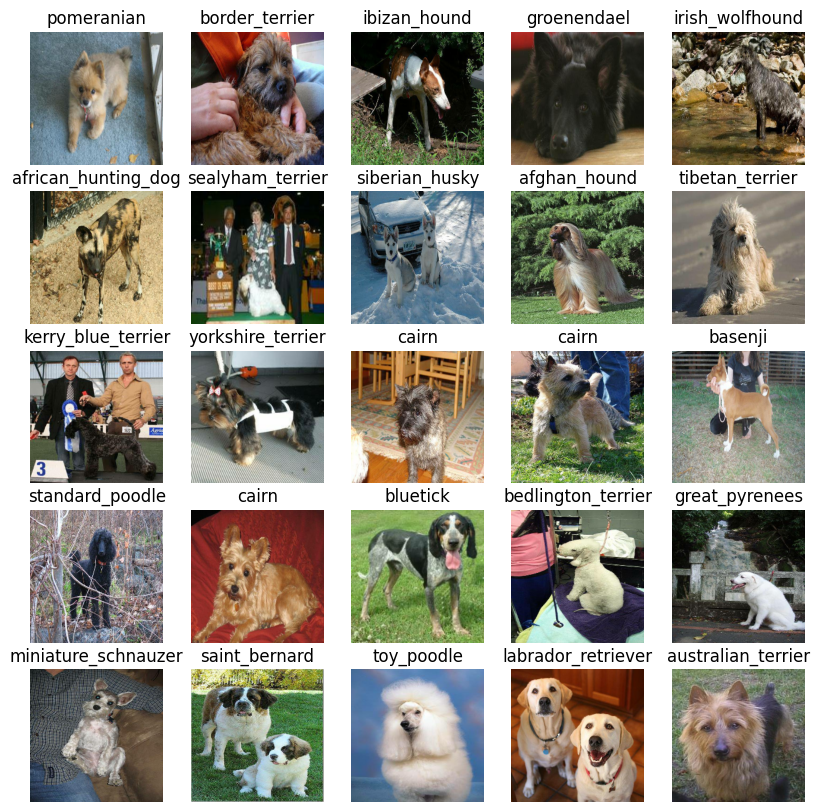

In [71]:
# Now let's visulise data in a training batch
show_25_image(train_images, train_labels)

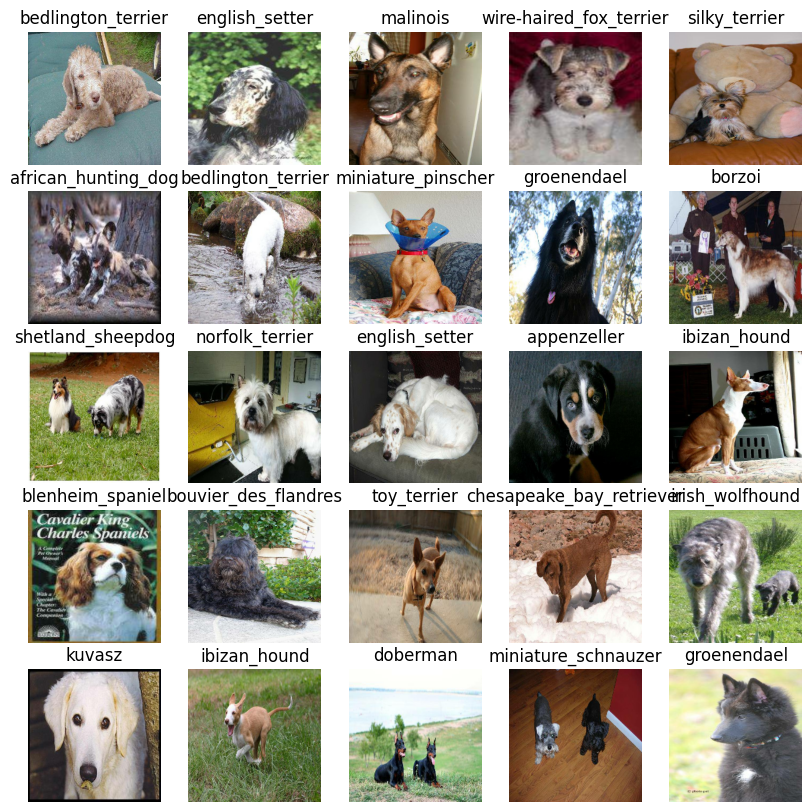

In [72]:
# Now let's visulise our validation batch
val_images, val_labels = next(val_data.as_numpy_iterator())
show_25_image(val_images,val_labels)

## Building a model
* The input shape (our images shape, in form of Tensors) to our model.
* The output shape (images labels, in the form of Tensors) of our model.
* The URL of the model we want to use.

In [74]:
IMG_SIZE

224

In [ ]:
# Setup the shape of the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3] # batch, height, width, colour channels

# Setup the shape of the model
OUTPUT_SHAPE = len(unique_breeds)

# Setup model URL from TensorFlow Hub
MODEL_URL = ...

In [ ]:
# Create a function which builds a Keras model

def create_model(input_shape = INPUT_SHAPE, output_shape = OUTPUT_SHAPE, model_url = MODEL_URL):
    print("Building model with: ", MODEL_URL)

    # Setup the model layers
    model = tf.keras.sequential([
        hub.KerasLayer(MODEL_URL), # Layer 1 (input layer)
        tf.kares.layers.Dense(units = OUTPUT_SHAPE,
                              activation = "softmax") # Layer 2 (output layer)
    ]) 

# Compile the model
model.compile(
   loss = tf.keras.losses.CatagoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# Build the model

model.build(INPUT_SHAPE)

return model

In [2]:
model = create_model()
model.summery()

NameError: name 'create_model' is not defined